In [1]:
import pandas as pd
df = pd.read_csv('data.csv')

print(df.head())
print(df.info())


                                                text              label
0  @ZubearSays Any real nigga isn't letting this ...     ethnicity/race
1  @MoradoSkittle @prolifejewess @DAConsult @Kell...  not_cyberbullying
2        the only thing i wish, i wish a nigga would     ethnicity/race
3  You saudias are not friends of Muslim idiots c...           religion
4  @JaydenT2399 @TractorLaw @holmes_gael @erconge...           religion
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99990 entries, 0 to 99989
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    99990 non-null  object
 1   label   99990 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None


In [2]:

print(f"Number of duplicates: {df.duplicated(subset='text').sum()}")
df = df.drop_duplicates(subset='text', keep='first')


Number of duplicates: 1


In [3]:
import re

def normalize_text(text):
    text = text.lower() 
    text = re.sub(r'http\S+|www\S+', '', text) 
    text = re.sub(r'@\w+', '', text) 
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

df['cleaned_text'] = df['text'].apply(normalize_text)


In [5]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

df['tokens'] = df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chiki\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chiki\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chiki\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'ethnicity/race': 0, 'gender/sexual': 1, 'not_cyberbullying': 2, 'religion': 3}


In [9]:

df.to_csv('preprocessed_data.csv', index=False)
df.head()


,text,label,cleaned_text,tokens,label_encoded
0,@ZubearSays Any real nigga isn't letting this ...,ethnicity/race,any real nigga isnt letting this happen,"[real, nigga, isnt, letting, happen]",0
1,@MoradoSkittle @prolifejewess @DAConsult @Kell...,not_cyberbullying,i didnt even mention mexico but the us is far ...,"[didnt, even, mention, mexico, u, far, safest,...",2
2,"the only thing i wish, i wish a nigga would",ethnicity/race,the only thing i wish i wish a nigga would,"[thing, wish, wish, nigga, would]",0
3,You saudias are not friends of Muslim idiots c...,religion,you saudias are not friends of muslim idiots c...,"[saudias, friend, muslim, idiot, cheapless, pe...",3
4,@JaydenT2399 @TractorLaw @holmes_gael @erconge...,religion,and yet the maga want to do just that the juda...,"[yet, maga, want, judah, christian, muslim, be...",3


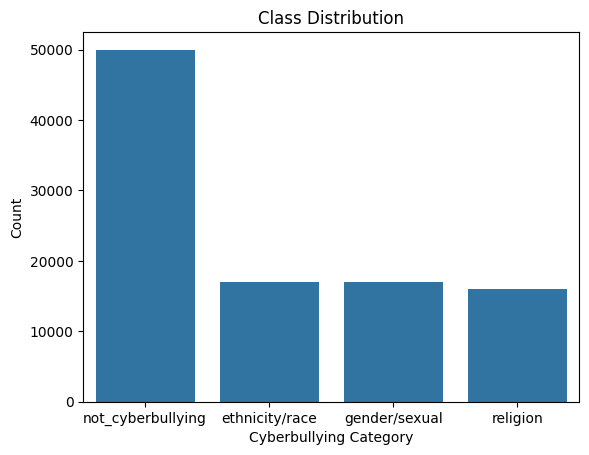

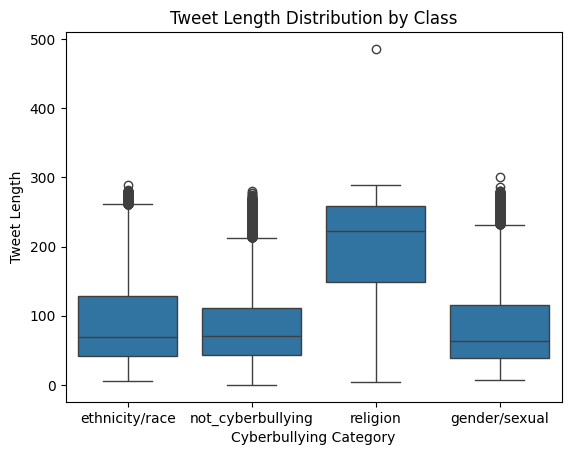

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df, order=df['label'].value_counts().index)
plt.title('Class Distribution')
plt.xlabel('Cyberbullying Category')
plt.ylabel('Count')
plt.show()

df['tweet_length'] = df['cleaned_text'].apply(len)

sns.boxplot(x='label', y='tweet_length', data=df)
plt.title('Tweet Length Distribution by Class')
plt.xlabel('Cyberbullying Category')
plt.ylabel('Tweet Length')
plt.show()


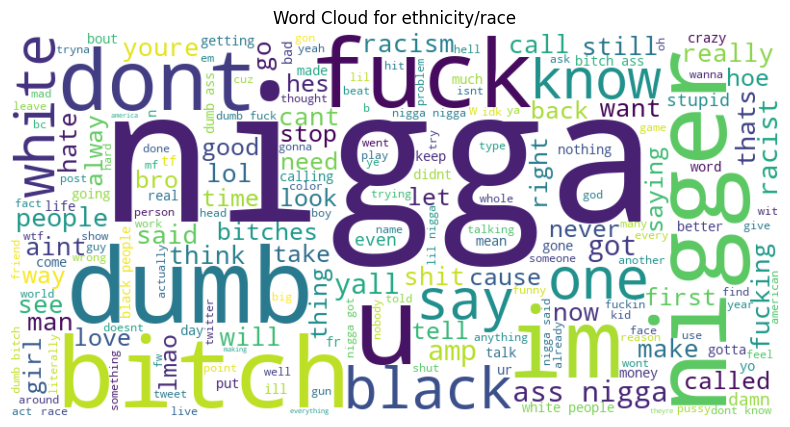

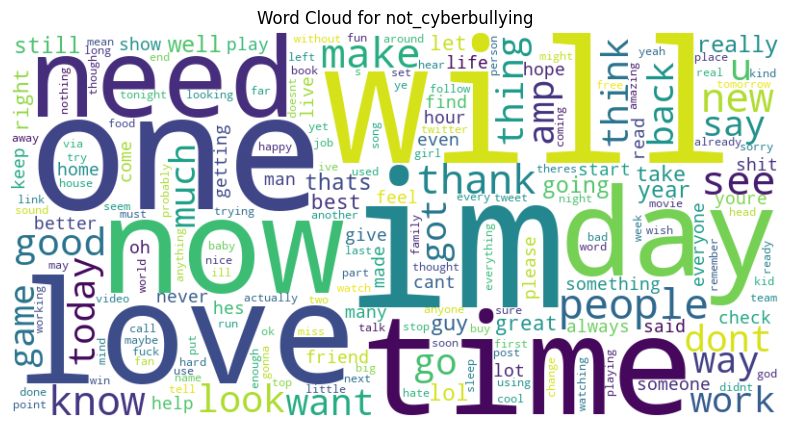

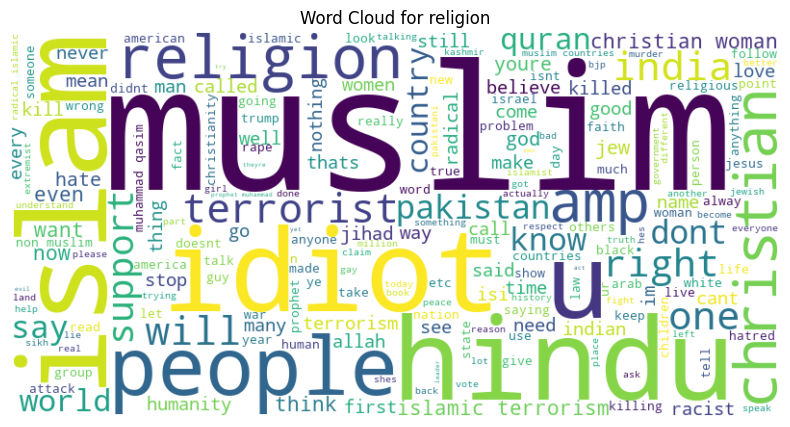

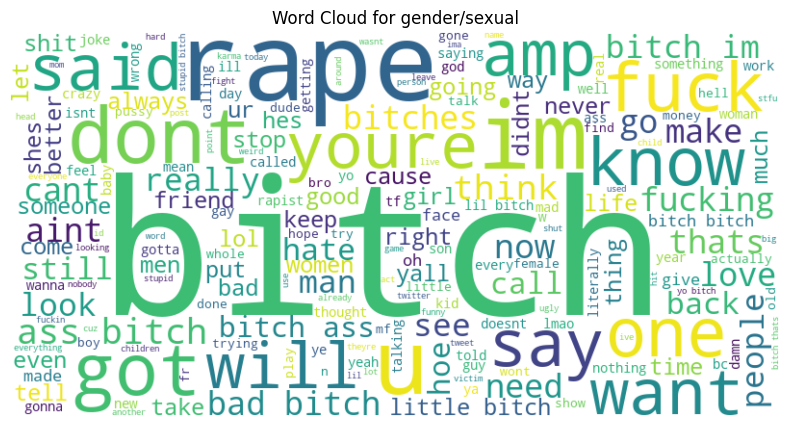

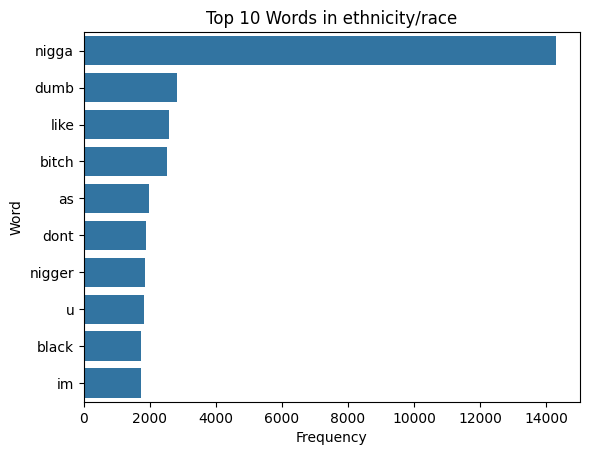

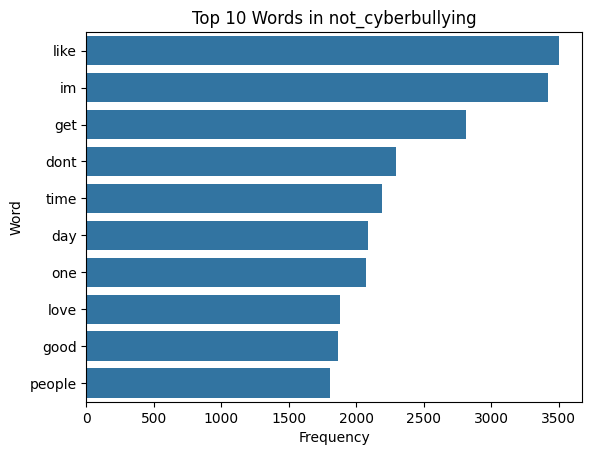

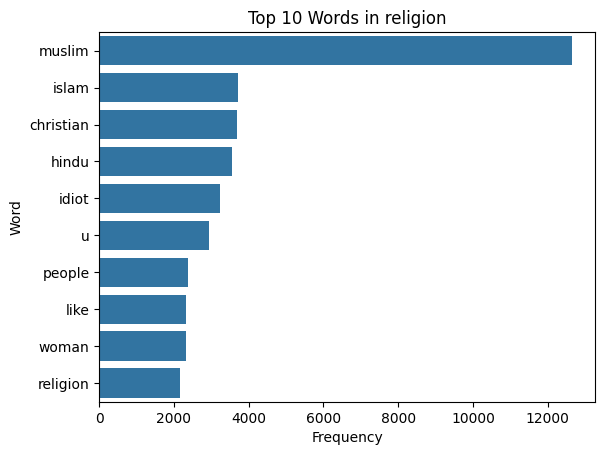

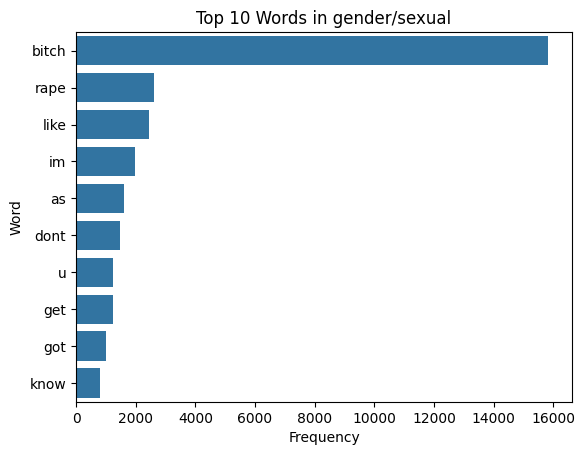

In [12]:
from wordcloud import WordCloud

for label in df['label'].unique():
    text = ' '.join(df[df['label'] == label]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label}')
    plt.axis('off')
    plt.show()

from collections import Counter

for label in df['label'].unique():
    all_words = [word for tokens in df[df['label'] == label]['tokens'] for word in tokens]
    freq_dist = Counter(all_words).most_common(10)
    freq_df = pd.DataFrame(freq_dist, columns=['Word', 'Frequency'])

    sns.barplot(x='Frequency', y='Word', data=freq_df)
    plt.title(f'Top 10 Words in {label}')
    plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\chiki\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


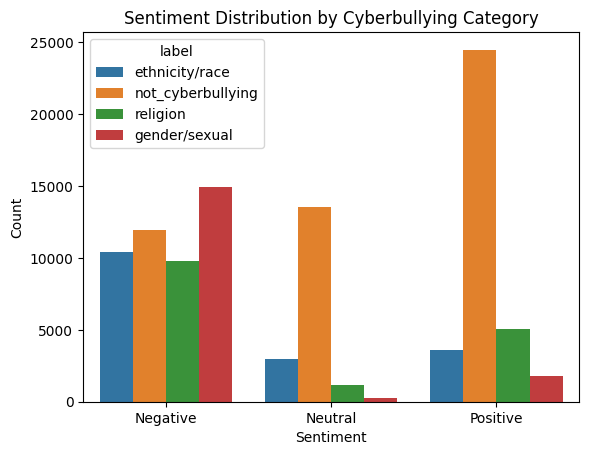

In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['cleaned_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df['sentiment_category'] = pd.cut(df['sentiment'], bins=[-1, -0.05, 0.05, 1], labels=['Negative', 'Neutral', 'Positive'])
sns.countplot(x='sentiment_category', hue='label', data=df)
plt.title('Sentiment Distribution by Cyberbullying Category')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


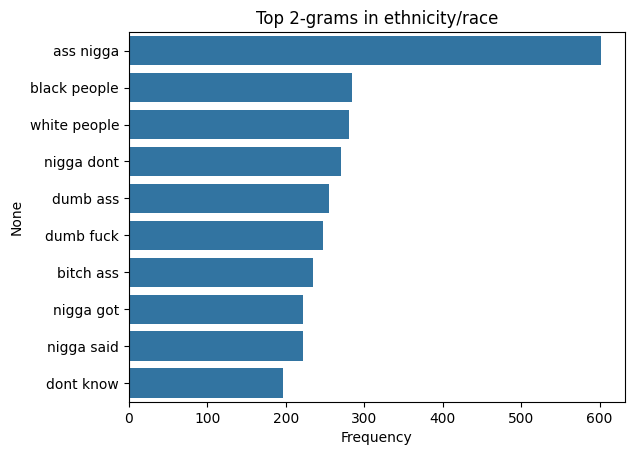

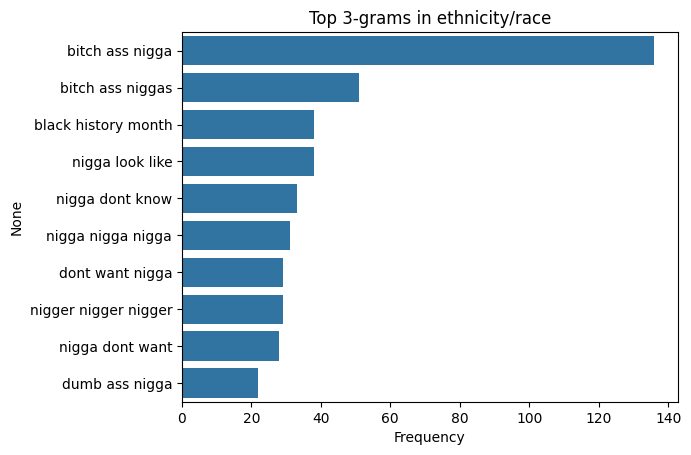

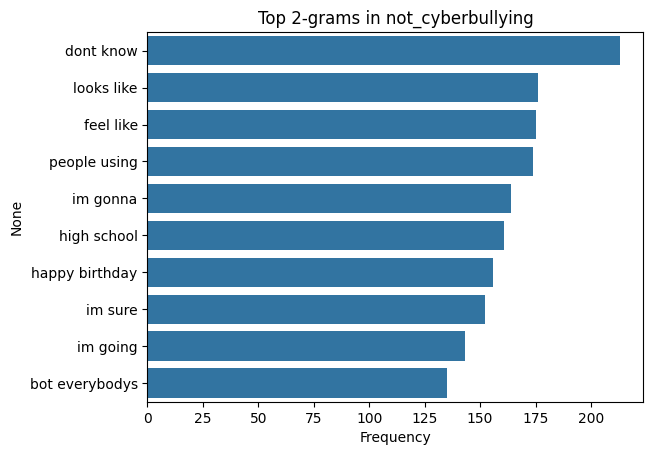

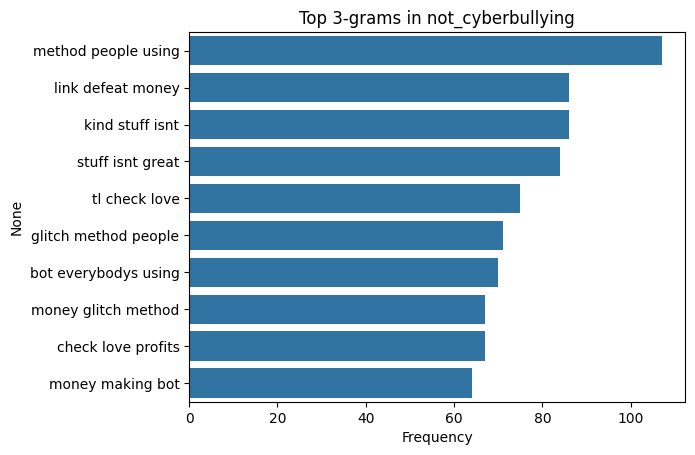

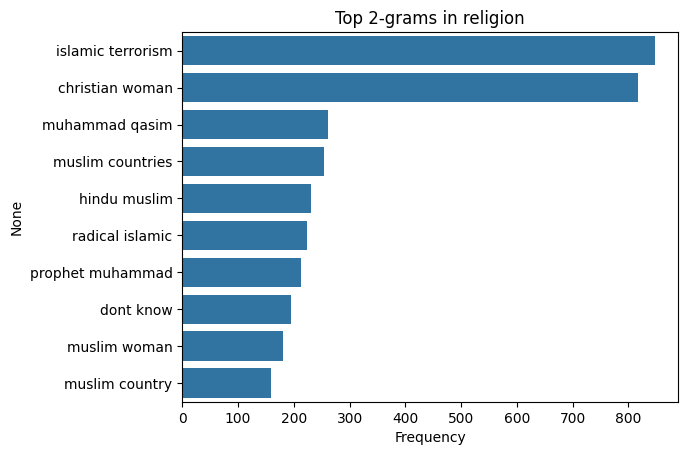

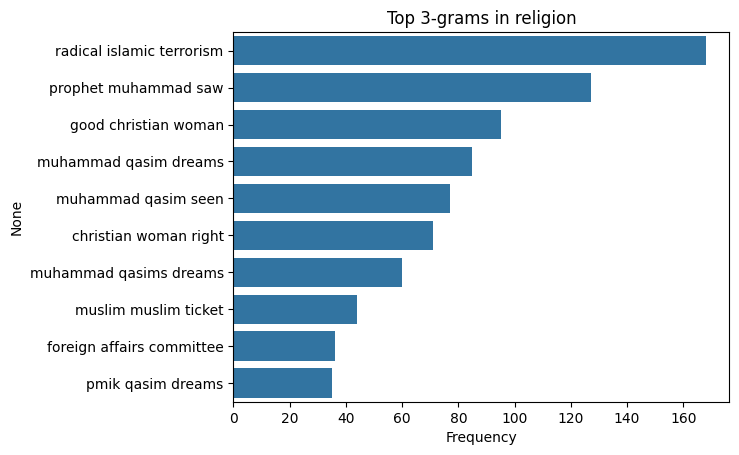

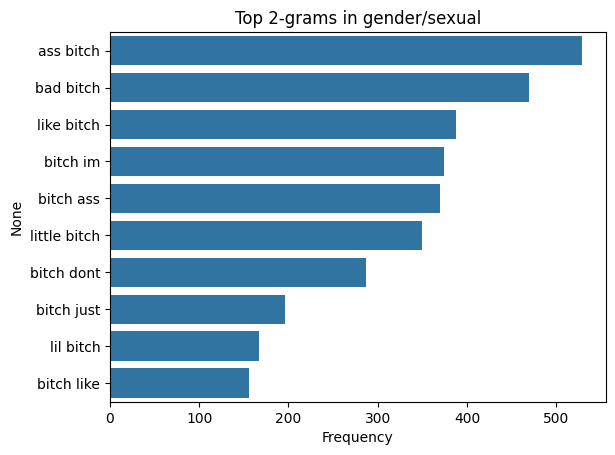

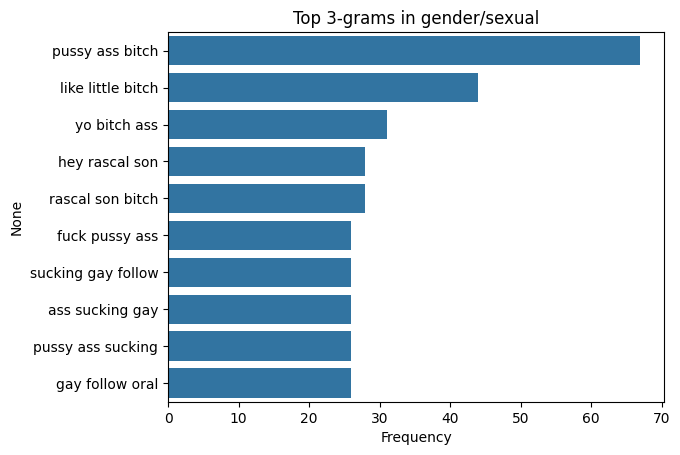

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_ngrams(category, n=2):
    text_data = df[df['label'] == category]['cleaned_text']
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words='english')
    ngram_counts = vectorizer.fit_transform(text_data)
    ngram_freq = pd.DataFrame(ngram_counts.sum(axis=0), columns=vectorizer.get_feature_names_out()).T
    ngram_freq.columns = ['Frequency']
    ngram_freq = ngram_freq.sort_values(by='Frequency', ascending=False).head(10)

    sns.barplot(x='Frequency', y=ngram_freq.index, data=ngram_freq)
    plt.title(f'Top {n}-grams in {category}')
    plt.show()

for label in df['label'].unique():
    plot_ngrams(label, n=2)  
    plot_ngrams(label, n=3)  


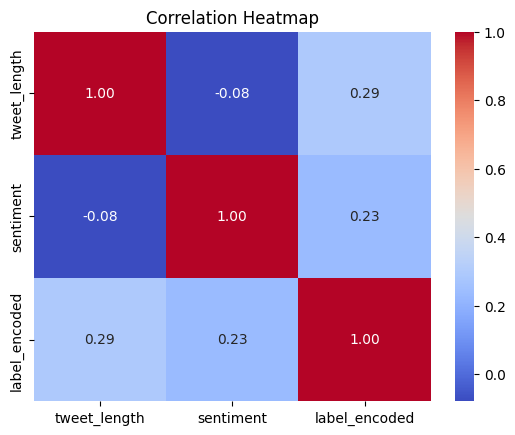

In [15]:

corr = df[['tweet_length', 'sentiment', 'label_encoded']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


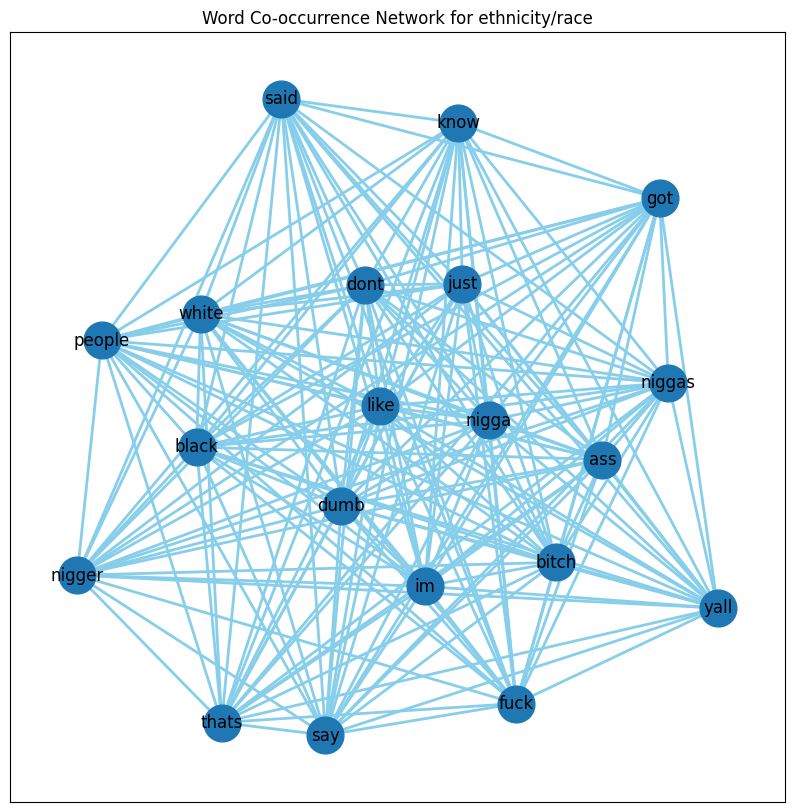

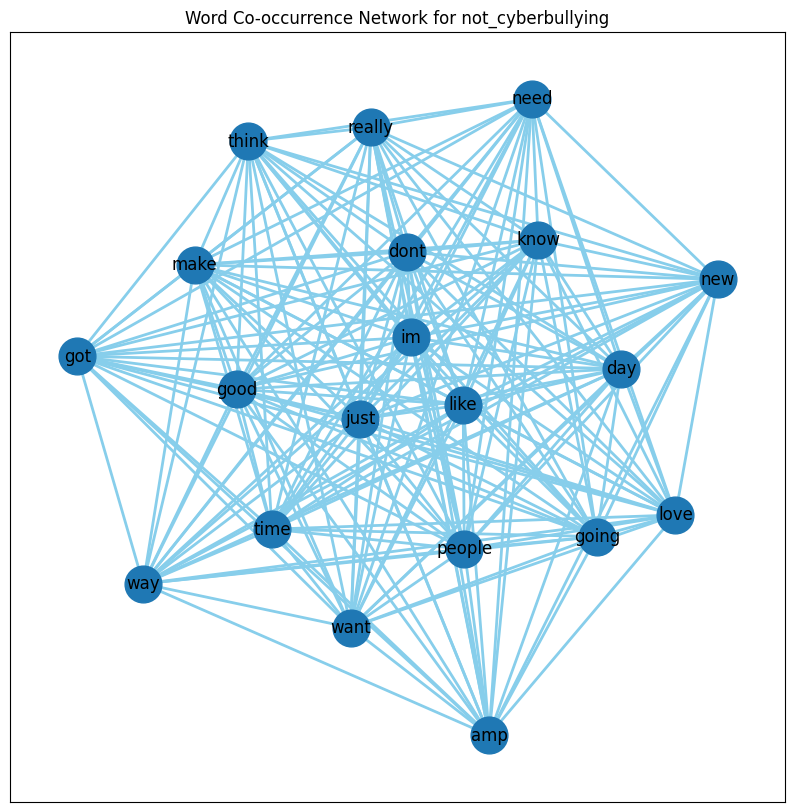

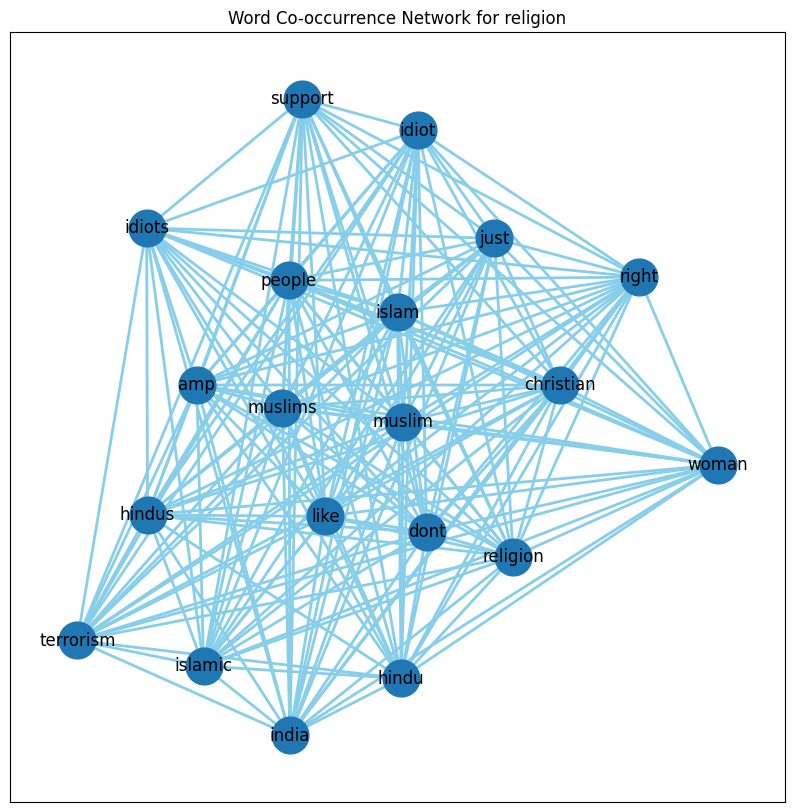

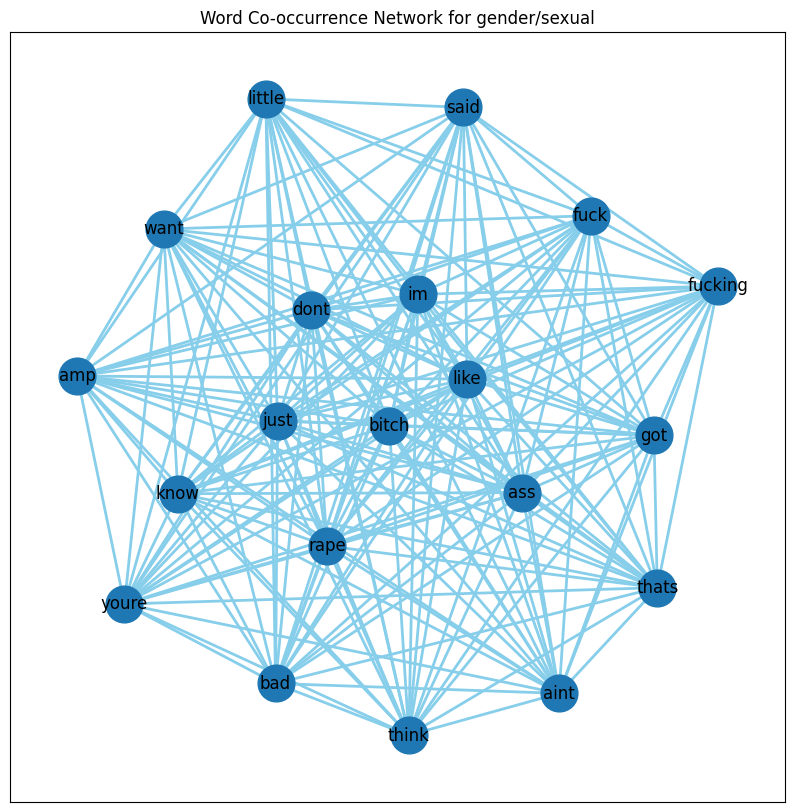

In [16]:
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer

def plot_cooccurrence_network(category, top_n=20):
    text_data = df[df['label'] == category]['cleaned_text']
    vectorizer = CountVectorizer(max_features=top_n, ngram_range=(1, 1), stop_words='english')
    X = vectorizer.fit_transform(text_data)
    cooccurrence_matrix = (X.T @ X).toarray()

    G = nx.Graph()
    terms = vectorizer.get_feature_names_out()
    for i in range(len(terms)):
        for j in range(i + 1, len(terms)):
            if cooccurrence_matrix[i, j] > 0:
                G.add_edge(terms[i], terms[j], weight=cooccurrence_matrix[i, j])

    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw_networkx(G, pos, with_labels=True, node_size=700, font_size=12, edge_color="skyblue", width=2)
    plt.title(f'Word Co-occurrence Network for {category}')
    plt.show()


for label in df['label'].unique():
    plot_cooccurrence_network(label)


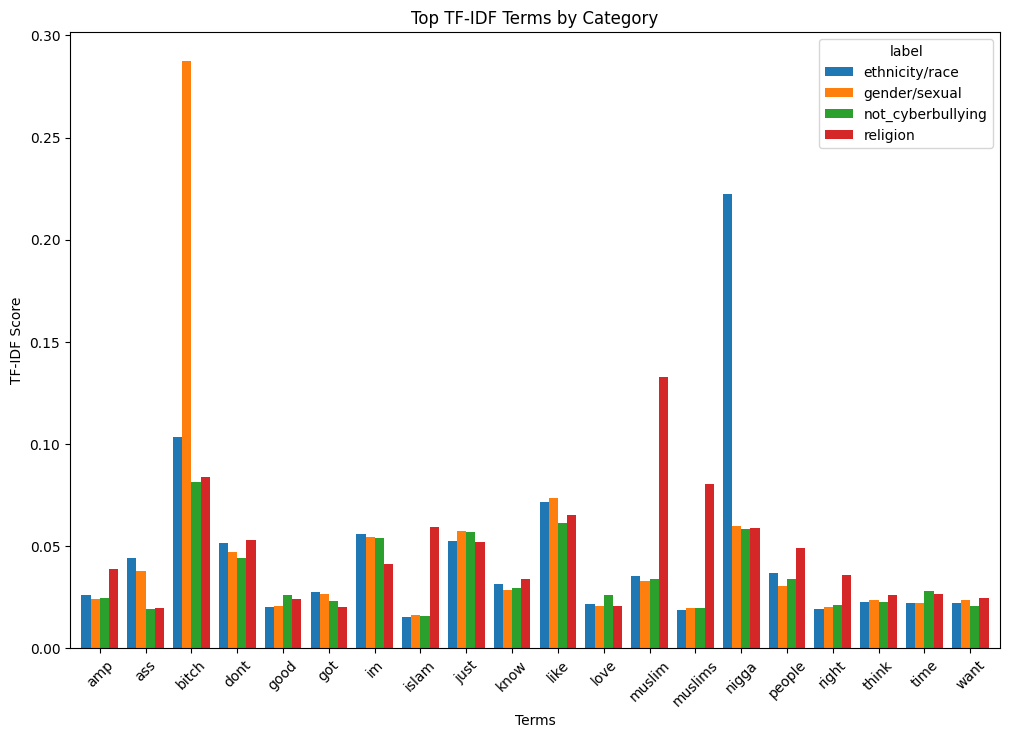

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd


tfidf_vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])


tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df['label'] = df['label']

tfidf_means = tfidf_df.groupby('label').mean().T


tfidf_means.plot(kind='bar', figsize=(12, 8), width=0.8)
plt.title('Top TF-IDF Terms by Category')
plt.ylabel('TF-IDF Score')
plt.xlabel('Terms')
plt.xticks(rotation=45)
plt.show()
